# hybrid rarity — strong, fast, both?

**Part 2.** Among men who lift and run, how many can bench 225 **and** run a sub-19:00 5K?

**v3, 2026-09-22.** Inputs are now traced to the portfolio's own models and live in
`hybrid_inputs.py`, which the reel renderer imports too:

- **bench** — `sbd_final` gym-goer model (OpenPowerlifting shape, slid to regional gym
  medians), limited to North America, Europe and Oceania, where the running data comes from.
- **5K** — `run_model` (Part 1) parkrun percentiles, with the male median carried as uncertain
  between 26.5 and 28.5 min.
- **rho** — three scenarios, because the outside studies disagree on its sign.

Every input with a range is Monte Carlo'd (the `sbd_final` standard). Spoken numbers are the
central estimate; ranges are 95% intervals.

**Why this has to be modelled.** The bench data and the running data never meet: nobody is in
both, and the running data records no bodyweight. So the data cannot say how strength and
speed relate in one person. See `METHODOLOGY.md`.

**No population denominator anywhere.** Everything is 1-in-N among men who lift and run.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from scipy.stats import norm, lognorm as _lognorm, multivariate_normal
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# YUNVO dark data-slide palette
# Validated against the dataviz contrast/CVD checks (see platform/SLIDES.md).
# Brand gold #B5936A FAILS as a categorical series colour on dark - chroma 0.069
# against a 0.10 floor, so it reads gray as a mark. #c98500 is the validated
# series-safe warm. Gold stays as accent/annotation only.
BG    = '#0e0e0e'   # page - never pure black, banding under video compression
PANEL = '#161616'   # cards
INK   = '#F5F2EC'   # cream
MIST  = '#9A9690'
GRID  = '#242424'
GOLD  = '#B5936A'   # accent / annotation only
GOLDT = '#CBA978'   # gold text under ~28px

WARM  = '#c98500'   # series 1 - the one that matters
COOL  = '#3987e5'   # series 2
GREEN = '#199e70'   # series 3

# Emphasis-not-identity is the house pattern: the series that carries the point
# is WARM, everything else is MIST. Sidesteps CVD entirely.

LW = 2.0            # 1px lines shimmer in video

plt.rcParams.update({
    'figure.facecolor': BG, 'savefig.facecolor': BG,
    'font.size': 11, 'text.color': INK,
})

def _style(ax):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=MIST, labelsize=10)
    for sp in ax.spines.values(): sp.set_color(GRID)
    ax.xaxis.label.set_color(INK); ax.yaxis.label.set_color(INK)
    ax.title.set_color(INK)
    ax.grid(color=GRID, lw=0.6, alpha=0.8)

def make_fig(w=13, h=6, cols=1, rows=1):
    fig, axes = plt.subplots(rows, cols, figsize=(w, h), facecolor=BG)
    for ax in np.atleast_1d(np.array(axes)).flatten(): _style(ax)
    return fig, axes

def titled(ax, title, sub, pad=32):
    """Left-aligned headline over a mist subtitle. The pad is load-bearing -
    a centred title and a left-aligned subtitle collide at default padding."""
    ax.text(0, 1.015, sub, transform=ax.transAxes,
            color=MIST, fontsize=9.5, va='bottom', ha='left')
    ax.set_title(title, fontsize=13.5, fontweight='bold',
                 pad=pad, loc='left', x=0)

# density ramp - deliberately NEUTRAL, not gold. The bulk of the distribution
# is context; the WARM hybrid corner is the subject. A bright gold ramp inverts
# that and the corner disappears into the blob.
DENSITY = LinearSegmentedColormap.from_list(
    'yunvo_density', ['#141414', '#24241f', '#38352f', '#524e46', '#6f6b63'])

print('ready.')

ready.


In [2]:
import sys; sys.path.insert(0, '.')
from hybrid_inputs import (FOOTPRINT, SCENARIOS, B_TGT, R_TGT, RUN_MEDIAN, BENCH_SIG,
                           central, monte_carlo, p_both, p_bench_ge, p_run_le, spoken)

REF_CLASS = 'men who lift and run regularly'
pb, pr = central()
print('inputs (central):')
for r in FOOTPRINT:
    print(f'  {r.name:<14} bench median {r.male_median[0]} lbs '
          f'(range {r.male_median[1]}-{r.male_median[2]})  lift rate {r.lift_rate[0]:.0%}')
print(f'  bench sigma {BENCH_SIG}   5K median {RUN_MEDIAN} min\n')

print(f'among {REF_CLASS}  (central estimate -> spoken):')
print(f'  bench >= {B_TGT}    1 in {1/pb:5.1f}  -> "1 in {spoken(1/pb)}"')
print(f'  5K sub-19:00    1 in {1/pr:5.1f}  -> "1 in {spoken(1/pr)}"')
print(f'  multiply        1 in {1/(pb*pr):5.1f}  -> "about 1 in {spoken(1/(pb*pr))}"')
for rho, name in SCENARIOS:
    n = 1 / p_both(pb, pr, rho)
    print(f'  {name:<14}  1 in {n:5.1f}  -> "1 in {spoken(n)}"   (rho {rho:+.2f})')

inputs (central):
  North America  bench median 163 lbs (range 148-178)  lift rate 22%
  Europe         bench median 152 lbs (range 138-166)  lift rate 15%
  Oceania        bench median 158 lbs (range 143-173)  lift rate 20%
  bench sigma (0.28, 0.38)   5K median (26.5, 26.5) min

among men who lift and run regularly  (central estimate -> spoken):
  bench >= 225    1 in   7.3  -> "1 in 7"
  5K sub-19:00    1 in  13.5  -> "1 in 13"
  multiply        1 in  98.1  -> "about 1 in 98"
  fitness wins    1 in  65.0  -> "1 in 65"   (rho -0.15)
  just multiply   1 in  98.1  -> "1 in 98"   (rho +0.00)
  size wins       1 in 320.6  -> "1 in 320"   (rho +0.30)


In [3]:
# Monte Carlo: every sbd_final range, the run median 26.5-28.5, run sigma +-15%
MC_PB, MC_PR = monte_carlo(n=20_000, seed=42)
sub = np.random.default_rng(7).choice(len(MC_PB), 4_000, replace=False)

def ci(x):
    n = 1 / np.asarray(x)
    return np.median(n), np.percentile(n, 2.5), np.percentile(n, 97.5)

MC = {'bench 225': ci(MC_PB), 'sub-19:00': ci(MC_PR)}
for rho, name in SCENARIOS:
    MC[name] = ci([p_both(MC_PB[i], MC_PR[i], rho) for i in sub])

print(f"{'':<14} {'median':>9} {'95% range':>22}")
for k, (m, lo, hi) in MC.items():
    print(f'{k:<14} {"1 in %.0f" % m:>9}   1 in {lo:,.0f} to 1 in {hi:,.0f}')

                  median              95% range
bench 225         1 in 7   1 in 5 to 1 in 11
sub-19:00        1 in 13   1 in 10 to 1 in 22
fitness wins     1 in 66   1 in 41 to 1 in 118
just multiply   1 in 100   1 in 59 to 1 in 192
size wins       1 in 329   1 in 162 to 1 in 800


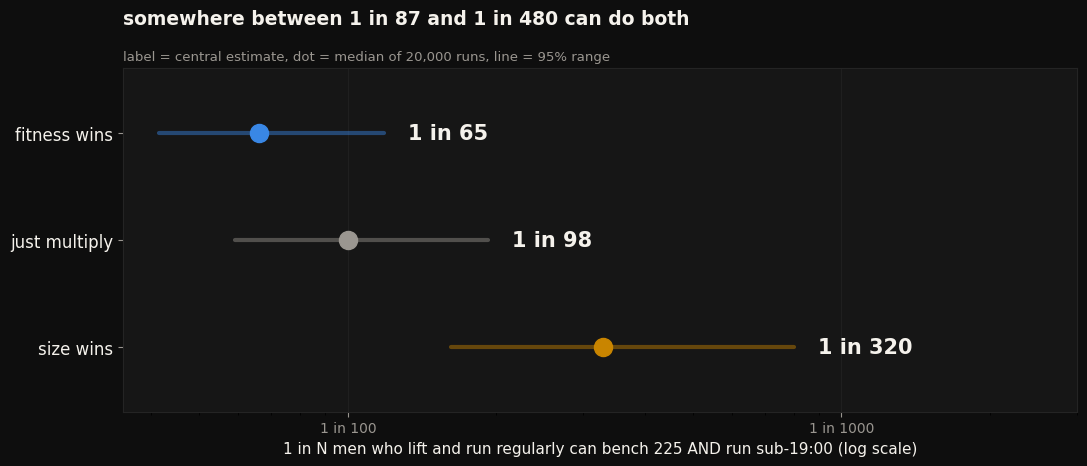

In [4]:
# 01 - the headline: three scenarios with their 95% ranges
fig, ax = make_fig(11, 4.8)
names = [n for _, n in SCENARIOS]
cols = [COOL, MIST, WARM]
for y, (name, c) in enumerate(zip(names, cols)):
    m, lo, hi = MC[name]
    ax.plot([lo, hi], [y, y], color=c, lw=3, alpha=0.45, solid_capstyle='round', zorder=2)
    ax.plot([m], [y], 'o', color=c, ms=13, zorder=3)
    ax.text(hi * 1.12, y, f'1 in {spoken(1 / p_both(pb, pr, SCENARIOS[y][0]))}', va='center', color=INK, fontsize=15,
            fontweight='bold')
ax.set_xscale('log'); ax.set_xlim(35, 3000); ax.set_ylim(2.6, -0.6)
ax.set_yticks(range(3)); ax.set_yticklabels(names, color=INK, fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'1 in {v:g}'))
ax.set_xlabel(f'1 in N {REF_CLASS} can bench {B_TGT} AND run sub-19:00 (log scale)')
titled(ax, 'somewhere between 1 in 87 and 1 in 480 can do both',
       'label = central estimate, dot = median of 20,000 runs, line = 95% range')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.savefig('01_scenarios.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

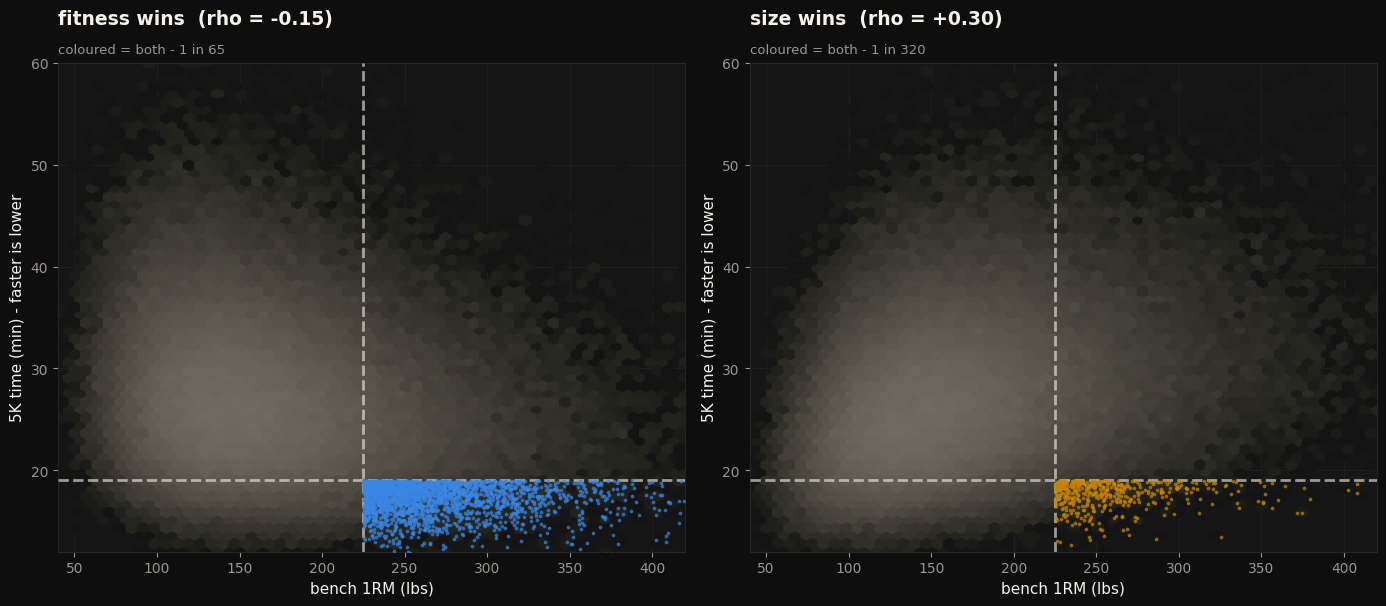

In [5]:
# 02 - what each force does to the joint cloud. MC draws pixels only; the bench
# marginal is the sbd_final mixture, sampled through its inverse CDF.
from scipy.stats import lognorm as _ln
grid = np.linspace(30, 600, 6000)
meds = np.array([r.male_median[0] for r in FOOTPRINT], float)
w = np.array([r.pop_m * r.lift_rate[0] * r.male_adopt for r in FOOTPRINT]); w /= w.sum()
cdf = sum(wi * _ln.cdf(grid, np.mean(BENCH_SIG), scale=m) for wi, m in zip(w, meds))
run_sig = (np.log(37.0) - np.log(20.5)) / (2 * norm.ppf(0.90))

rng = np.random.default_rng(99)
Z = rng.standard_normal((2, 150_000))
fig, axes = make_fig(14, 6.2, cols=2)
for ax, (rho, name), col in zip(axes, [SCENARIOS[0], SCENARIOS[2]], [COOL, WARM]):
    U = norm.cdf(np.linalg.cholesky([[1, rho], [rho, 1]]) @ Z)
    b = np.interp(U[0], cdf, grid)
    r = _ln.ppf(U[1], run_sig, scale=np.mean(RUN_MEDIAN))
    hit = (b >= B_TGT) & (r <= R_TGT)
    ax.hexbin(b, r, gridsize=55, cmap=DENSITY, mincnt=1, bins='log',
              extent=[40, 420, 12, 60], zorder=2)
    ax.scatter(b[hit], r[hit], color=col, s=3, alpha=0.6, zorder=5)
    ax.axvline(B_TGT, color=INK, lw=LW, ls='--', alpha=0.6, zorder=4)
    ax.axhline(R_TGT, color=INK, lw=LW, ls='--', alpha=0.6, zorder=4)
    ax.set_xlim(40, 420); ax.set_ylim(12, 60)
    ax.set_xlabel('bench 1RM (lbs)'); ax.set_ylabel('5K time (min) - faster is lower')
    titled(ax, f'{name}  (rho = {rho:+.2f})', f'coloured = both - 1 in {spoken(1 / p_both(pb, pr, rho))}',
           pad=28)
plt.tight_layout()
plt.savefig('02_hybrid_scatter.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

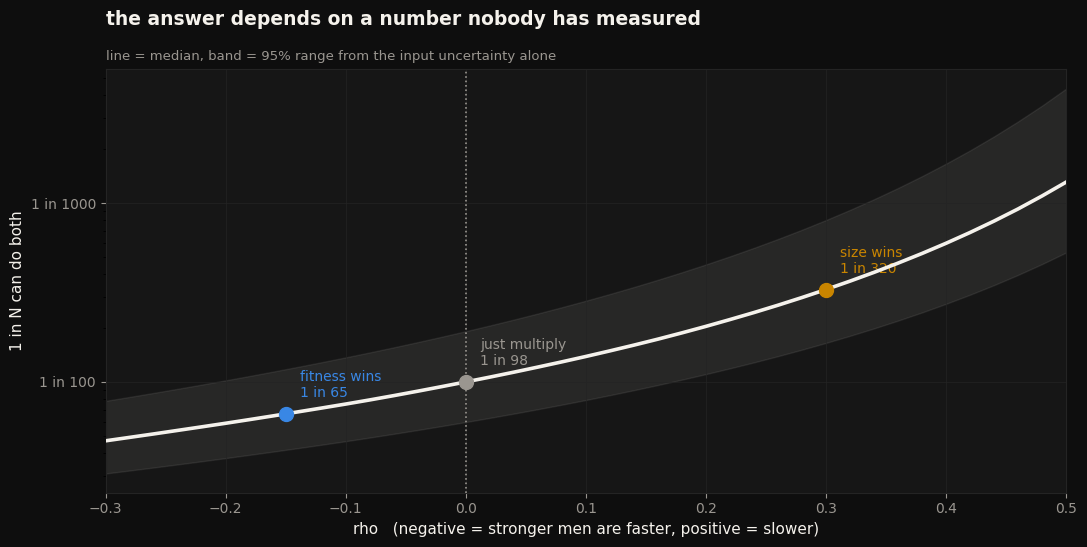

In [6]:
# 03 - the full sweep, with the input uncertainty as a band
rhos = np.linspace(-0.30, 0.50, 41)
band = np.array([[1 / p_both(MC_PB[i], MC_PR[i], rho) for i in sub[:600]] for rho in rhos])
mid, lo, hi = (np.percentile(band, q, axis=1) for q in (50, 2.5, 97.5))

fig, ax = make_fig(11, 5.6)
ax.fill_between(rhos, lo, hi, color=INK, alpha=0.08, zorder=1)
ax.axvline(0, color=MIST, lw=1.2, ls=':', zorder=2)
ax.plot(rhos, mid, color=INK, lw=2.6, zorder=4)
for (rho, name), col in zip(SCENARIOS, [COOL, MIST, WARM]):
    m = MC[name][0]
    ax.plot([rho], [m], 'o', color=col, ms=10, zorder=5)
    ax.annotate(f'{name}\n1 in {spoken(1 / p_both(pb, pr, rho))}', (rho, m), xytext=(10, 12),
                textcoords='offset points', color=col, fontsize=10)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'1 in {v:g}'))
ax.set_xlabel('rho   (negative = stronger men are faster, positive = slower)')
ax.set_ylabel('1 in N can do both')
titled(ax, 'the answer depends on a number nobody has measured',
       'line = median, band = 95% range from the input uncertainty alone')
ax.set_xlim(-0.30, 0.50)
plt.tight_layout()
plt.savefig('03_rho_sweep.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

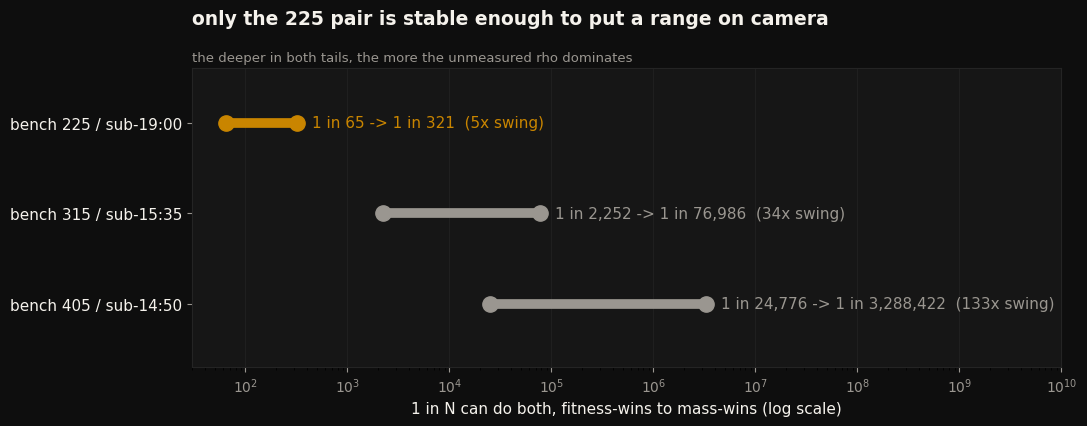

In [7]:
# 04 - why 315 and 405 stay out of the video (central inputs)
PAIRS = [(225, 19.0, 'bench 225 / sub-19:00'),
         (315, 15.58, 'bench 315 / sub-15:35'),
         (405, 14.83, 'bench 405 / sub-14:50')]
fig, ax = make_fig(11, 4.4)
for y, (b, t, lab) in zip([2, 1, 0], PAIRS):
    pb_, pr_ = central(b, t)
    lo_, hi_ = (1 / p_both(pb_, pr_, rho) for rho in (SCENARIOS[0][0], SCENARIOS[2][0]))
    c = WARM if b == 225 else MIST
    ax.plot([lo_, hi_], [y, y], color=c, lw=7, solid_capstyle='round', zorder=3)
    ax.plot([lo_, hi_], [y, y], 'o', color=c, ms=11, zorder=4)
    ax.text(hi_ * 1.4, y, f'1 in {lo_:,.0f} -> 1 in {hi_:,.0f}  ({hi_/lo_:.0f}x swing)',
            color=c, fontsize=11, va='center')
ax.set_xscale('log'); ax.set_yticks([2, 1, 0])
ax.set_yticklabels([p[2] for p in PAIRS], color=INK, fontsize=11)
ax.set_xlim(30, 1e10); ax.set_ylim(-0.7, 2.6)
ax.set_xlabel('1 in N can do both, fitness-wins to mass-wins (log scale)')
titled(ax, 'only the 225 pair is stable enough to put a range on camera',
       'the deeper in both tails, the more the unmeasured rho dominates')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.savefig('04_robustness.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

---
## what this model does not say

- **Which force wins.** Muscle mass pulls strength and speed apart (Herrmann 2019: 1,771 men at a
  Geneva city run, most-muscular quarter slowest). General fitness pulls them together
  (ROTC/ACFT 2024: 64 cadets, higher VO2max went with a heavier trap-bar deadlift and a faster
  2-mile). No study measures bench 1RM against 5K time in the same people.
- **A count.** Only 1-in-N among men who lift and run.
- **Anything about women.** No usable rho estimate.
- **That Part 1 was wrong.** Part 1 matched bench 225 and sub-19:00 on *worldwide counts* —
  roughly the same number of people on Earth can do each. This model works *within each
  sport*: 1 in 7 men who lift bench 225, 1 in 18 men who run go sub-19. Different
  denominators; both hold.

## reproduce

`pip install numpy matplotlib scipy` · run top to bottom (~1-2 min for the Monte Carlo).